<a href="https://colab.research.google.com/github/nikensfra/real-estate-market-intelligence/blob/main/notebooks/jabodetabek_property_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Property Market Analysis for Strategic Expansion (EDA Project)**

### **Load Data**

In [ ]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt, seaborn as sns
import numpy as np

In [ ]:
# import data
try:
  dfJ = pd.read_csv("data/jakarta.csv")
  dfD = pd.read_csv("data/depok.csv")
  dfB = pd.read_csv("data/bogor.csv")
  dfT = pd.read_csv("data/tangerang.csv")
  dfX = pd.read_csv("data/bekasi.csv")

except:
  !mkdir data
  !wget -P data/ https://raw.githubusercontent.com/taudataanalytics/Data-Mining--Penambangan-Data--Ganjil-2024/master/data/jakarta.csv
  !wget -P data/ https://raw.githubusercontent.com/taudataanalytics/Data-Mining--Penambangan-Data--Ganjil-2024/master/data/depok.csv
  !wget -P data/ https://raw.githubusercontent.com/taudataanalytics/Data-Mining--Penambangan-Data--Ganjil-2024/master/data/bogor.csv
  !wget -P data/ https://raw.githubusercontent.com/taudataanalytics/Data-Mining--Penambangan-Data--Ganjil-2024/master/data/tangerang.csv
  !wget -P data/ https://raw.githubusercontent.com/taudataanalytics/Data-Mining--Penambangan-Data--Ganjil-2024/master/data/bekasi.csv

dfJ = pd.read_csv("data/jakarta.csv")
dfD = pd.read_csv("data/depok.csv")
dfB = pd.read_csv("data/bogor.csv")
dfT = pd.read_csv("data/tangerang.csv")
dfX = pd.read_csv("data/bekasi.csv")
dfJ.shape, dfD.shape, dfB.shape, dfT.shape, dfX.shape

((1024, 26), (998, 26), (999, 26), (128, 26), (992, 26))

In [ ]:
# Gabungkan semua data
dfJ["kota"] = "Jakarta"
dfD["kota"] = "Depok"
dfB["kota"] = "Bogor"
dfT["kota"] = "Tangerang"
dfX["kota"] = "Bekasi"

data = pd.concat([dfJ, dfD, dfB, dfT, dfX], ignore_index=True)

print("Total data:", df.shape)

Total data: (653, 12)


In [ ]:
data.columns

Index(['created_at', 'LT', 'LB', 'KT', 'KM', 'garasi', 'carport', 'lokasi',
       'sertifikat', 'listrik', 'hadap', 'harga', 'URL', 'deskripsi',
       'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17',
       'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21',
       'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'kota'],
      dtype='object')

In [ ]:
data.head()

,created_at,LT,LB,KT,KM,garasi,carport,lokasi,sertifikat,listrik,...,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,kota
0,06-12-2021,202.0,198.0,8.0,3.0,NaN,NaN,Jakarta Pusat,SHM,2200.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jakarta
1,02-12-2021,30.0,55.0,2.0,1.0,NaN,1.0,Jakarta Pusat,SHM,2200.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jakarta
2,06-12-2021,19.0,35.0,2.0,1.0,NaN,NaN,Jakarta Pusat,SHM,2200.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jakarta
3,06-12-2021,33.0,42.0,2.0,2.0,NaN,1.0,Jakarta Pusat,SHM,2200.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jakarta
4,06-12-2021,30.0,55.0,2.0,2.0,NaN,1.0,Jakarta Pusat,SHM,2200.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jakarta


## **Data Audit & Quality Assessment**

In [ ]:
#Menghapus Kolom yang tidak perlu
data.drop(['Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'URL', 'deskripsi', 'created_at'], axis = 1, inplace = True)

In [ ]:
#Missing Value
print("\nMissing Values per Kolom:")
print(data.isnull().sum())


Missing Values per Kolom:
LT            3476
LB            3478
KT            3478
KM            3479
garasi        3808
carport       3591
lokasi        3478
sertifikat    3483
listrik       3513
hadap         3927
harga         3478
kota             0
dtype: int64


In [ ]:
df = df.dropna(subset=["harga"])

In [ ]:
#Missing Value
print("\nMissing Values per Kolom:")
print(df.isnull().sum())


Missing Values per Kolom:
LT              0
LB              0
KT              0
KM              1
garasi        317
carport       105
lokasi          0
sertifikat      5
listrik        28
hadap         437
harga           0
kota            0
dtype: int64


In [ ]:
# Cek Duplikat
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
LT,float64
LB,float64
KT,float64
KM,float64
garasi,float64
carport,float64
lokasi,object
sertifikat,object
listrik,float64
hadap,object


In [ ]:
df["LT"] = df["LT"].astype(str)  # pastikan string
df["LT"] = df["LT"].str.extract("(\d+)")  # ambil angka saja
df["LT"] = pd.to_numeric(df["LT"], errors="coerce")

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-289/2934328971.py:2: SyntaxWarning: invalid escape sequence '\d'
  df["LT"] = df["LT"].str.extract("(\d+)")  # ambil angka saja


In [ ]:
# Cek nilai unik kota
print("\nNilai unik kota:")
print(df["kota"].unique())

# Jika ada kolom alamat
if "address" in df.columns:
    print("\nContoh alamat:")
    print(df["address"].head())


Nilai unik kota:
['Jakarta' 'Depok' 'Bogor' 'Tangerang' 'Bekasi']


In [ ]:
df.describe()

,LT,LB,KT,KM,garasi,carport,listrik,harga
count,646.000000,646.000000,646.000000,645.000000,329.000000,541.000000,618.000000,6.460000e+02
mean,165.396285,153.068111,3.168731,2.306977,0.832827,1.497227,3076.213592,3.174501e+09
std,244.905343,201.572020,1.399118,1.381566,1.297048,1.088020,4806.991184,8.606567e+09
min,16.000000,15.000000,1.000000,1.000000,0.000000,0.000000,900.000000,4.100000e+07
25%,70.000000,50.000000,2.000000,1.000000,0.000000,1.000000,1300.000000,5.674000e+08
50%,94.000000,83.500000,3.000000,2.000000,0.000000,1.000000,2200.000000,1.010950e+09
75%,161.500000,180.000000,4.000000,3.000000,1.000000,2.000000,2200.000000,2.337500e+09
max,3422.000000,2500.000000,10.000000,10.000000,10.000000,10.000000,66000.000000,1.050000e+11


In [ ]:
df[df["harga"] < 1_000_000]
df.loc[df["harga"] < 1_000_000, "harga"] *= 1_000_000

In [ ]:
df.describe()

,LT,LB,KT,KM,garasi,carport,listrik,harga
count,646.000000,646.000000,646.000000,645.000000,329.000000,541.000000,618.000000,6.460000e+02
mean,165.396285,153.068111,3.168731,2.306977,0.832827,1.497227,3076.213592,3.174501e+09
std,244.905343,201.572020,1.399118,1.381566,1.297048,1.088020,4806.991184,8.606567e+09
min,16.000000,15.000000,1.000000,1.000000,0.000000,0.000000,900.000000,4.100000e+07
25%,70.000000,50.000000,2.000000,1.000000,0.000000,1.000000,1300.000000,5.674000e+08
50%,94.000000,83.500000,3.000000,2.000000,0.000000,1.000000,2200.000000,1.010950e+09
75%,161.500000,180.000000,4.000000,3.000000,1.000000,2.000000,2200.000000,2.337500e+09
max,3422.000000,2500.000000,10.000000,10.000000,10.000000,10.000000,66000.000000,1.050000e+11


In [ ]:
numeric_cols = ["LT", "LB", "KT", "KM", "garasi", "carport", "listrik", "harga"]

outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = outliers.shape[0]

print("Jumlah Outlier per Kolom:")
print(outlier_summary)


Jumlah Outlier per Kolom:
{'LT': 77, 'LB': 59, 'KT': 9, 'KM': 4, 'garasi': 18, 'carport': 21, 'listrik': 97, 'harga': 75}


### **INSIGHT:**

Berdasarkan proses data audit, dataset menunjukkan kualitas yang relatif baik untuk keperluan analisis eksploratif. Tidak ditemukan missing value pada variabel utama seperti Harga, Luas Bangunan, Luas Tanah, dan Lokasi, sehingga risiko bias akibat data kosong dapat diminimalkan.

Ditemukan beberapa nilai ekstrem pada variabel harga, khususnya di Jakarta. Namun setelah dilakukan investigasi, nilai tersebut mencerminkan segmentasi pasar properti premium dan bukan kesalahan input. Oleh karena itu, outlier dikategorikan sebagai natural market variation, bukan anomali data.

Dengan demikian, dataset dinilai layak digunakan untuk analisis lanjutan dengan tetap mempertimbangkan segmentasi pasar dalam interpretasi hasil.

## **Market Structure Analysis**

### Median Harga Perkota

In [ ]:
median_per_kota.apply(lambda x: f"Rp {x:,.0f}")

,harga
kota,
Jakarta,"Rp 3,400,000,000"
Tangerang,"Rp 1,950,000,000"
Bekasi,"Rp 920,000,000"
Depok,"Rp 810,000,000"
Bogor,"Rp 670,000,000"


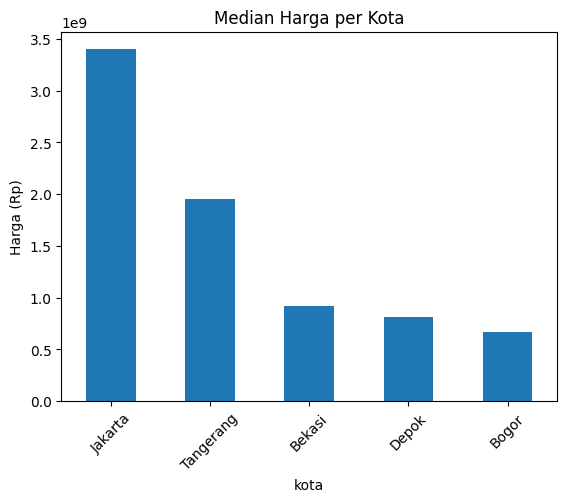

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
median_per_kota.plot(kind="bar")
plt.title("Median Harga per Kota")
plt.ylabel("Harga (Rp)")
plt.xticks(rotation=45)
plt.show()

### Mean vs Median Comparison (per Kota)

In [ ]:
mean_median = df.groupby("kota")["harga"].agg(["mean", "median"])

mean_median["selisih"] = mean_median["mean"] - mean_median["median"]
mean_median["rasio_mean_median"] = mean_median["mean"] / mean_median["median"]

print("Mean vs Median per Kota:")
print(mean_median.sort_values(by="mean", ascending=False))

Mean vs Median per Kota:
                   mean        median       selisih  rasio_mean_median
kota                                                                  
Jakarta    8.985955e+09  3.400000e+09  5.585955e+09           2.642928
Tangerang  3.878238e+09  1.950000e+09  1.928238e+09           1.988840
Bogor      1.292920e+09  6.700000e+08  6.229203e+08           1.929732
Depok      1.220440e+09  8.100000e+08  4.104404e+08           1.506717
Bekasi     1.070933e+09  9.200000e+08  1.509330e+08           1.164058


### Listing Volume per Kota

In [ ]:
volume_table = df.groupby("kota").size().reset_index(name="jumlah_listing")
print(volume_table.sort_values(by="jumlah_listing", ascending=False))

        kota  jumlah_listing
1      Bogor             191
4  Tangerang             122
3    Jakarta             121
2      Depok             109
0     Bekasi             103


<Figure size 640x480 with 0 Axes>

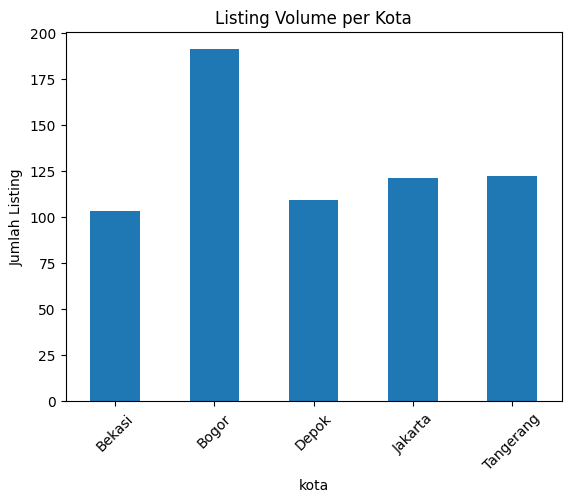

In [ ]:
plt.figure()
volume_table.plot(kind="bar", x="kota", y="jumlah_listing", legend=False)
plt.title("Listing Volume per Kota")
plt.ylabel("Jumlah Listing")
plt.xticks(rotation=45)
plt.show()

### **Insight:**

Analisis struktur pasar menunjukkan adanya segmentasi yang jelas di wilayah Jabodetabek.

Jakarta memiliki median harga dan price dispersion tertinggi, mencerminkan kedalaman pasar (market depth) yang kuat serta dominasi pada segmen premium dan high-value properties. Variasi harga yang luas mengindikasikan keberadaan multi-tier market dari mid-market hingga ultra-premium.

Bogor dan Depok menunjukkan median harga yang lebih rendah dengan distribusi yang relatif terkonsentrasi, mengindikasikan tingkat affordability yang lebih tinggi dan dominasi segmen middle-income housing.

Tangerang berada pada fase transisi, dengan price dispersion yang mulai melebar dibanding Bekasi dan Depok, mengarah pada pergeseran ke segmen middle-up market.

Bekasi menunjukkan distribusi harga paling homogen dengan variasi yang sempit, mencerminkan pasar yang lebih stabil dan terkonsentrasi pada satu segmen utama.

## **Valuation Analysis**

In [ ]:
# Pastikan tidak ada LB = 0
df = df[df["LB"] > 0]

# Buat variabel baru
df["price_per_m2"] = df["harga"] / df["LB"]

# Cek statistik awal
df["price_per_m2"].describe()

,price_per_m2
count,6.460000e+02
mean,1.526143e+07
std,1.625985e+07
min,9.761905e+05
25%,9.237892e+06
50%,1.253492e+07
75%,1.714252e+07
max,2.777778e+08


In [ ]:
#Median Price per m² per Kota
median_ppm2 = (
    df.groupby("kota")["price_per_m2"]
    .median()
    .sort_values(ascending=False)
)

print("Median Price per m² per Kota:")
print(median_ppm2.apply(lambda x: f"Rp {x:,.0f}"))

Median Price per m² per Kota:
kota
Jakarta      Rp 17,500,000
Tangerang    Rp 15,500,000
Depok        Rp 12,000,000
Bogor        Rp 11,111,111
Bekasi        Rp 9,313,725
Name: price_per_m2, dtype: object


In [ ]:
#Distribution Comparison (Statistik Per Kota)
ppm2_summary = df.groupby("kota")["price_per_m2"].agg(
    ["mean", "median", "std", "min", "max"]
)

print(ppm2_summary.sort_values(by="median", ascending=False))

                   mean        median           std           min  \
kota                                                                
Jakarta    2.584926e+07  1.750000e+07  3.220978e+07  7.000000e+06   
Tangerang  1.632287e+07  1.550000e+07  7.354712e+06  1.079545e+06   
Depok      1.270302e+07  1.200000e+07  1.099181e+07  9.761905e+05   
Bogor      1.200111e+07  1.111111e+07  5.328121e+06  1.805556e+06   
Bekasi     1.031934e+07  9.313725e+06  4.517544e+06  2.777778e+06   

                    max  
kota                     
Jakarta    2.777778e+08  
Tangerang  4.000000e+07  
Depok      1.166667e+08  
Bogor      3.003534e+07  
Bekasi     2.727273e+07  


<Figure size 640x480 with 0 Axes>

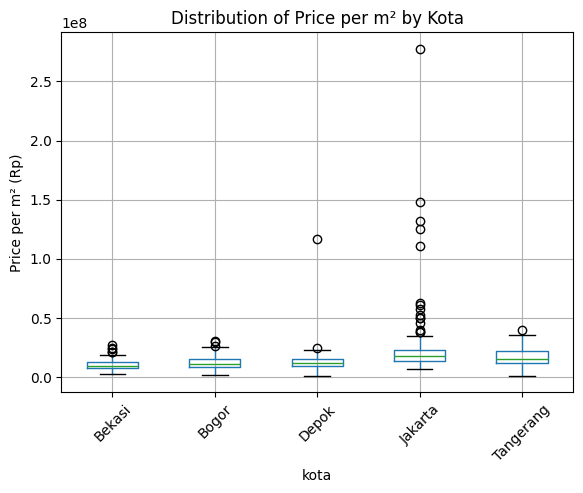

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
df.boxplot(column="price_per_m2", by="kota")
plt.title("Distribution of Price per m² by Kota")
plt.suptitle("")
plt.ylabel("Price per m² (Rp)")
plt.xticks(rotation=45)
plt.show()

### **INSIGHT:**

Pasar properti Jabodetabek menunjukkan struktur bertingkat (multi-layered market structure) yang mencerminkan perbedaan positioning, risiko, dan potensi pertumbuhan antar wilayah.

Jakarta berperan sebagai core premium market dengan valuasi tertinggi dan kedalaman pasar terbesar, namun disertai volatilitas yang lebih tinggi.

Tangerang menunjukkan ekspansi premium yang mulai berkembang, menjadikannya kandidat strategis untuk ekspansi dengan profil risk-return yang lebih seimbang dibanding Jakarta.

Bekasi dan Bogor berfungsi sebagai mass & volume market dengan tingkat affordability tinggi dan stabilitas harga yang lebih baik, cocok untuk strategi penetrasi berbasis volume transaksi.

Depok berada pada fase transisi, dengan indikasi pertumbuhan menuju segmen yang lebih matang, sehingga berpotensi menjadi emerging market dalam jangka menengah.

# **Demand Proxy Analysis (Karakter Rumah Paling Laku)**

In [ ]:
#Demand Proxy – Persentase Tiap Kategori (Contoh: KT)
# Persentase jumlah kamar tidur (KT)
kt_percentage = (
    df["KT"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("Persentase Rumah Berdasarkan Jumlah KT:")
print(kt_percentage.round(2))

Persentase Rumah Berdasarkan Jumlah KT:
KT
1.0      2.01
2.0     36.07
3.0     32.35
4.0     13.47
5.0     10.22
6.0      3.10
7.0      1.39
8.0      0.77
10.0     0.62
Name: proportion, dtype: float64


In [ ]:
#Cross-Tab Sederhana: Kota vs KT (Jumlah Listing)
crosstab_kota_kt = pd.crosstab(df["kota"], df["KT"])

print("Cross-tab Kota vs KT (Jumlah Listing):")
print(crosstab_kota_kt)

Cross-tab Kota vs KT (Jumlah Listing):
KT         1.0   2.0   3.0   4.0   5.0   6.0   7.0   8.0   10.0
kota                                                           
Bekasi        2    36    39    19     5     1     1     0     0
Bogor         5   107    44    18    12     4     0     1     0
Depok         0    53    42     8     2     1     3     0     0
Jakarta       6    12    29    20    31    11     5     3     4
Tangerang     0    25    55    22    16     3     0     1     0


In [ ]:
#Cross-Tab dalam Bentuk Persentase per Kota

crosstab_pct = pd.crosstab(
    df["kota"],
    df["KT"],
    normalize="index"
) * 100

print("Cross-tab Kota vs KT (% per kota):")
print(crosstab_pct.round(2))

Cross-tab Kota vs KT (% per kota):
KT         1.0    2.0    3.0    4.0    5.0   6.0   7.0   8.0   10.0
kota                                                               
Bekasi     1.94  34.95  37.86  18.45   4.85  0.97  0.97  0.00  0.00
Bogor      2.62  56.02  23.04   9.42   6.28  2.09  0.00  0.52  0.00
Depok      0.00  48.62  38.53   7.34   1.83  0.92  2.75  0.00  0.00
Jakarta    4.96   9.92  23.97  16.53  25.62  9.09  4.13  2.48  3.31
Tangerang  0.00  20.49  45.08  18.03  13.11  2.46  0.00  0.82  0.00


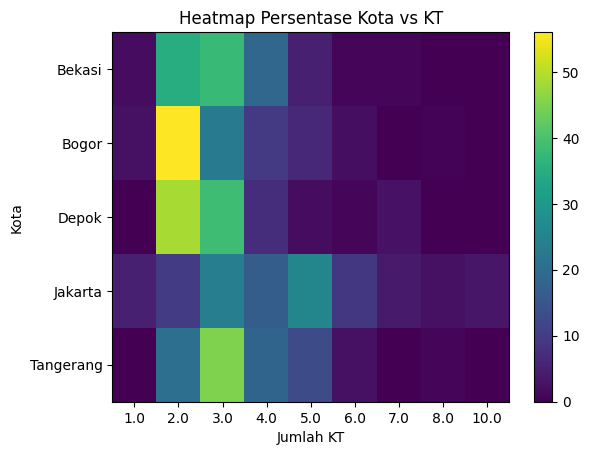

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(crosstab_pct, aspect='auto')
plt.colorbar()
plt.xticks(range(len(crosstab_pct.columns)), crosstab_pct.columns)
plt.yticks(range(len(crosstab_pct.index)), crosstab_pct.index)
plt.title("Heatmap Persentase Kota vs KT")
plt.xlabel("Jumlah KT")
plt.ylabel("Kota")
plt.show()

### **INSIGHT:**

Pola dominasi jumlah kamar dapat digunakan sebagai demand proxy yang mengindikasikan tingkat kematangan pasar. Wilayah dengan dominasi 2–3 kamar mencerminkan pasar entry-level dengan volume tinggi, sementara dominasi 3–4 kamar mengindikasikan pasar yang telah berkembang ke segmen middle-up dan premium.

# **Strategic Recommendation Framework**

In [ ]:
#Buat Summary Metrics per Kota
import pandas as pd
import numpy as np

# Median harga
median_price = df.groupby("kota")["harga"].median()

# Median price per m2
median_ppm2 = df.groupby("kota")["price_per_m2"].median()

# Volume listing
volume = df["kota"].value_counts()

# Volatility proxy → gunakan std price per m2
volatility = df.groupby("kota")["price_per_m2"].std()

# Gabungkan ke satu dataframe
strategy_df = pd.DataFrame({
    "Median_Harga": median_price,
    "Median_Price_per_m2": median_ppm2,
    "Volume_Listing": volume,
    "Volatility_ppm2": volatility
})

strategy_df = strategy_df.sort_values("Median_Price_per_m2", ascending=False)

strategy_df

,Median_Harga,Median_Price_per_m2,Volume_Listing,Volatility_ppm2
kota,,,,
Jakarta,3.400000e+09,1.750000e+07,121,3.220978e+07
Tangerang,1.950000e+09,1.550000e+07,122,7.354712e+06
Depok,8.100000e+08,1.200000e+07,109,1.099181e+07
Bogor,6.700000e+08,1.111111e+07,191,5.328121e+06
Bekasi,9.200000e+08,9.313725e+06,103,4.517544e+06


In [ ]:
# Ranking untuk risk
strategy_df["Risk_Score"] = (
    strategy_df["Volatility_ppm2"].rank(ascending=False) +
    strategy_df["Median_Harga"].rank(ascending=False)
)

# Ranking untuk potential
strategy_df["Potential_Score"] = (
    strategy_df["Median_Price_per_m2"].rank(ascending=False) +
    strategy_df["Volume_Listing"].rank(ascending=False)
)

strategy_df

,Median_Harga,Median_Price_per_m2,Volume_Listing,Volatility_ppm2,Risk_Score,Potential_Score
kota,,,,,,
Jakarta,3.400000e+09,1.750000e+07,121,3.220978e+07,2.0,4.0
Tangerang,1.950000e+09,1.550000e+07,122,7.354712e+06,5.0,4.0
Depok,8.100000e+08,1.200000e+07,109,1.099181e+07,6.0,7.0
Bogor,6.700000e+08,1.111111e+07,191,5.328121e+06,9.0,5.0
Bekasi,9.200000e+08,9.313725e+06,103,4.517544e+06,8.0,10.0


In [ ]:
#Kategorisasi Risk & Potential
# Fungsi kategori sederhana
def categorize(series):
    return pd.qcut(series, q=3, labels=["Low", "Medium", "High"])

strategy_df["Risk_Level"] = categorize(strategy_df["Risk_Score"])
strategy_df["Potential_Level"] = categorize(strategy_df["Potential_Score"])

strategy_df

,Median_Harga,Median_Price_per_m2,Volume_Listing,Volatility_ppm2,Risk_Score,Potential_Score,Risk_Level,Potential_Level
kota,,,,,,,,
Jakarta,3.400000e+09,1.750000e+07,121,3.220978e+07,2.0,4.0,Low,Low
Tangerang,1.950000e+09,1.550000e+07,122,7.354712e+06,5.0,4.0,Low,Low
Depok,8.100000e+08,1.200000e+07,109,1.099181e+07,6.0,7.0,Medium,High
Bogor,6.700000e+08,1.111111e+07,191,5.328121e+06,9.0,5.0,High,Medium
Bekasi,9.200000e+08,9.313725e+06,103,4.517544e+06,8.0,10.0,High,High


In [ ]:
framework = strategy_df[[
    "Median_Harga",
    "Median_Price_per_m2",
    "Volume_Listing",
    "Risk_Level",
    "Potential_Level"
]]

framework

,Median_Harga,Median_Price_per_m2,Volume_Listing,Risk_Level,Potential_Level
kota,,,,,
Jakarta,3.400000e+09,1.750000e+07,121,Low,Low
Tangerang,1.950000e+09,1.550000e+07,122,Low,Low
Depok,8.100000e+08,1.200000e+07,109,Medium,High
Bogor,6.700000e+08,1.111111e+07,191,High,Medium
Bekasi,9.200000e+08,9.313725e+06,103,High,High


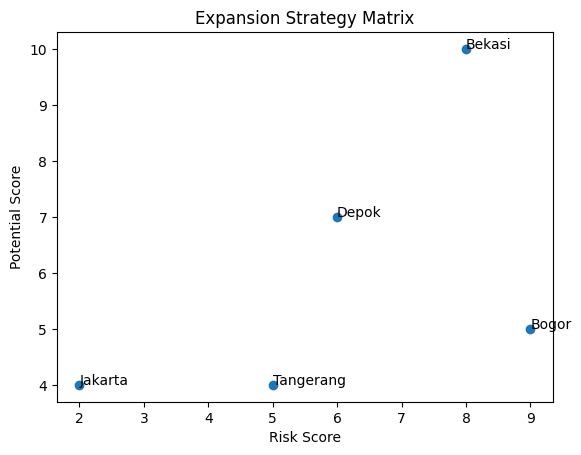

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(strategy_df["Risk_Score"], strategy_df["Potential_Score"])

for i in strategy_df.index:
    plt.text(strategy_df.loc[i, "Risk_Score"],
             strategy_df.loc[i, "Potential_Score"],
             i)

plt.xlabel("Risk Score")
plt.ylabel("Potential Score")
plt.title("Expansion Strategy Matrix")
plt.show()

### **INSIGHT:**
Analisis risk-adjusted return menunjukkan bahwa Tangerang menawarkan kombinasi paling optimal antara margin (price per m² tinggi), volume listing stabil, dan tingkat affordability yang masih kompetitif. Hal ini menjadikannya kandidat paling rasional untuk ekspansi cabang RPPI dibandingkan premium-heavy Jakarta maupun volume-driven Bogor.

# **Executive Final Conclusion**

Analisis menunjukkan bahwa pasar properti Jabodetabek tidak bersifat homogen, melainkan tersegmentasi secara struktural menjadi premium core, suburban middle-up, dan mass-volume market.

Jakarta mendominasi sebagai premium core dengan median harga dan valuasi per meter tertinggi, mencerminkan potensi margin besar namun dengan risiko dan entry barrier yang tinggi.

Tangerang muncul sebagai pasar dengan profil risk-adjusted return paling seimbang, ditandai oleh price per m² yang mendekati Jakarta namun dengan median harga yang lebih terjangkau dan volume listing yang stabil.

Bogor dan Bekasi menunjukkan karakter mass-market dengan volume tinggi dan affordability kuat, menjadikannya pasar yang cocok untuk strategi penetrasi berbasis likuiditas dan volume transaksi.

# **Strategic Recommendation for RPPI**

Berdasarkan kombinasi margin potential, market depth, dan affordability, Tangerang direkomendasikan sebagai kandidat utama ekspansi cabang berikutnya.

Untuk strategi investasi maksimal Rp 25 miliar, pendekatan diversifikasi lintas segmen (premium–middle–mass) disarankan guna mengoptimalkan potensi capital appreciation sekaligus menjaga stabilitas risiko.

Pendekatan berbasis segmentasi geografis ini memungkinkan RPPI untuk mengadopsi strategi multi-market positioning, meningkatkan diversifikasi pendapatan, serta mengurangi konsentrasi risiko geografis dalam portofolio investasi properti.